# Simulation Model Validation — Supplementary Figures

This notebook generates three supplementary figures validating the ABC-calibrated
simulation model for H5N1 B3.13 cattle epidemic spread.

- **Figure S-M08**: Simulation model validation (infection frequency + timing)
- **Figure S-StartDate**: Start date (tMRCA offset) sensitivity analysis
- **Figure S-StratOutcomes**: Stratified epidemic outcomes by tMRCA tertile

In [1]:
from pathlib import Path
from scipy import stats as sp_stats
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.dates as mdates
from datetime import datetime, timedelta

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
})
for font in ['Arial', 'Helvetica', 'DejaVu Sans']:
    try:
        plt.rcParams['font.family'] = font
        break
    except:
        pass

PROJ_ROOT = Path('../..').resolve()
FINAL_DIR = PROJ_ROOT / 'paper' / 'final'
PAPER_DIR = PROJ_ROOT / 'paper'
SIM_DIR = PROJ_ROOT / 'analysis' / 'simulations'
SCENARIO_DIR = SIM_DIR / 'outputs' / 'scenarios'
FIG_DIR = FINAL_DIR / 'figures'

with open(SIM_DIR / 'config.yaml') as f:
    config = yaml.safe_load(f)

OBSERVED_COUNTS = config['observed']['outbreak_counts']
OBSERVED_TIMING = config['observed']['first_detection_days']
APHIS_STATES = sorted(OBSERVED_COUNTS.keys())

N_SIMS = 375_000


def hpd(samples, credible_mass=0.95):
    sorted_samples = np.sort(samples)
    n = len(sorted_samples)
    interval_size = int(np.ceil(credible_mass * n))
    widths = sorted_samples[interval_size:] - sorted_samples[:n - interval_size]
    best = int(np.argmin(widths))
    return sorted_samples[best], sorted_samples[best + interval_size - 1]


def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


print(f'FINAL_DIR: {FINAL_DIR}')
print(f'SIM_DIR:   {SIM_DIR}')
print(f'FIG_DIR:   {FIG_DIR}')
print(f'APHIS states ({len(APHIS_STATES)}): {APHIS_STATES}')

FINAL_DIR: /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/paper/final
SIM_DIR:   /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/analysis/simulations
FIG_DIR:   /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/paper/final/figures
APHIS states (16): ['CA', 'CO', 'IA', 'ID', 'KS', 'MI', 'MN', 'NC', 'NE', 'NM', 'OH', 'OK', 'SD', 'TX', 'UT', 'WY']


## Load data

In [2]:
results = pd.read_csv(SCENARIO_DIR / 'npi_day35_results.csv')
state_detail = pd.read_csv(SCENARIO_DIR / 'npi_day35_state_detail.csv')
abc = pd.read_csv(SCENARIO_DIR / 'abc_accepted.csv')

print(f'Results: {len(results):,} rows')
print(f'State detail: {len(state_detail):,} rows')
print(f'ABC particles: {len(abc)}')
print(f'Unique states in state_detail: {state_detail["state"].nunique()}')

Results: 375,000 rows
State detail: 13,661,650 rows
ABC particles: 75
Unique states in state_detail: 48


---

## Figure S-M08: Simulation Model Validation

Two-panel figure showing (A) how frequently each state is infected across all
375,000 calibrated simulations, colored by median county spread, and (B) the
timing of first infection for APHIS-detected states compared to observed
detection dates.

- Panel A: The 16 APHIS states should have high infection frequencies;
  additional states at lower frequencies indicate plausible but less likely spread.
- Panel B: Observed detection dates (diamonds) should generally fall within the
  simulated arrival-time intervals, validating the model's temporal calibration.

In [3]:
state_freq = state_detail.groupby('state').size() / N_SIMS
state_med_counties = state_detail.groupby('state')['n_counties'].median()

# Build DataFrame, sort ascending so highest frequency plots at top
freq_df = pd.DataFrame({
    'freq': state_freq,
    'med_counties': state_med_counties
}).sort_values('freq', ascending=True)

# ── Panel B data: arrival-day distributions converted to calendar dates ──
# Each ABC particle has its own tmrca_offset; join to state_detail
abc_offsets = abc[['tmrca_offset']].reset_index().rename(columns={'index': 'param_idx'})
state_detail_cal = state_detail.merge(abc_offsets, on='param_idx', how='left')

tx_detection = datetime(2024, 3, 25)

all_timing_cal = {}
for st in freq_df.index:
    mask = state_detail_cal['state'] == st
    rows = state_detail_cal.loc[mask]
    if len(rows) > 0:
        cal_days = rows['arrival_day'].values - rows['tmrca_offset'].values
        all_timing_cal[st] = cal_days

# Median tmrca_offset from ABC (still useful for reference)
median_tmrca_offset = abc['tmrca_offset'].median()

# Panel B sort: by median calendar arrival (earliest at top)
median_arrival_cal = {st: np.median(arr) for st, arr in all_timing_cal.items()}
states_by_arrival = sorted(median_arrival_cal.keys(), key=lambda s: median_arrival_cal[s])

# Era assignment based on BEAST first-introduction dates (decimal years)
# from threeway.firstDetect.rateScalar3epoch GLM
npi_day = 35
TX_DET_DEC = 2024.2329
FED_ORD_DEC = 2024.3260

BEAST_FIRST_INTRO = {
    'TX': 2023.956, 'NM': 2024.134, 'KS': 2024.145, 'ID': 2024.161,
    'OH': 2024.180, 'SD': 2024.186, 'CO': 2024.186, 'NC': 2024.189,
    'MI': 2024.194, 'MN': 2024.254, 'IA': 2024.260, 'WY': 2024.268,
    'OK': 2024.281, 'CA': 2024.448, 'UT': 2024.527, 'NE': 2025.611,
}

era_colors_map = {
    'cryptic': '#d62728',
    'detection': '#ff7f0e',
    'post-order': '#2ca02c',
}

def get_era(st):
    if st not in BEAST_FIRST_INTRO:
        return None
    dec_year = BEAST_FIRST_INTRO[st]
    if dec_year < TX_DET_DEC:
        return 'cryptic'
    elif dec_year < FED_ORD_DEC:
        return 'detection'
    else:
        return 'post-order'

print(f'States with infections: {len(freq_df)}')
print(f'Median tMRCA offset (ABC): {median_tmrca_offset:.0f} days')
print(f'Panel B states: {len(states_by_arrival)}')
print(f'TX median calendar offset: {median_arrival_cal["TX"]:.1f} days relative to detection')
print(f'Era assignments: { {st: get_era(st) for st in BEAST_FIRST_INTRO} }')

States with infections: 48
Median tMRCA offset (ABC): 91 days
Panel B states: 48
TX median calendar offset: -91.0 days relative to detection
Era assignments: {'TX': 'cryptic', 'NM': 'cryptic', 'KS': 'cryptic', 'ID': 'cryptic', 'OH': 'cryptic', 'SD': 'cryptic', 'CO': 'cryptic', 'NC': 'cryptic', 'MI': 'cryptic', 'MN': 'detection', 'IA': 'detection', 'WY': 'detection', 'OK': 'detection', 'CA': 'post-order', 'UT': 'post-order', 'NE': 'post-order'}


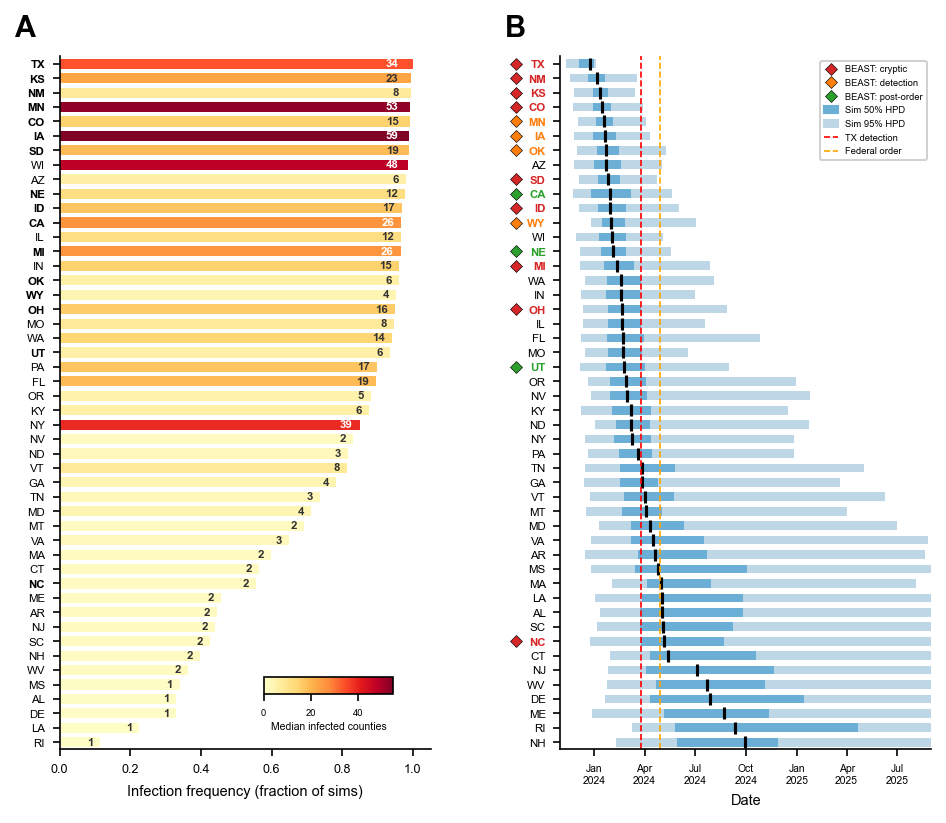

In [4]:
from matplotlib.lines import Line2D

n_states = len(freq_df)
n_b = len(states_by_arrival)
n_max = max(n_states, n_b)

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(7.5, 6),
                                  gridspec_kw={'wspace': 0.35})

##### Panel A: Infection frequency (sorted ascending, highest at top) #####
cmap = plt.cm.YlOrRd
norm = Normalize(vmin=0, vmax=55)

for i, (st, row) in enumerate(freq_df.iterrows()):
    color = cmap(norm(row['med_counties']))
    ax_a.barh(i, row['freq'], height=0.7, color=color, edgecolor='none')
    if row['med_counties'] > 0:
        mc = row['med_counties']
        ax_a.text(
            min(row['freq'], 0.98) - 0.02, i,
            f'{int(mc)}',
            va='center', ha='right', fontsize=5.5,
            color='white' if mc > 25 else '#333',
            fontweight='bold',
        )

ax_a.set_yticks(np.arange(n_states))
ax_a.set_yticklabels(list(freq_df.index), fontsize=5.5)
for tick_label in ax_a.get_yticklabels():
    if tick_label.get_text() in BEAST_FIRST_INTRO:
        tick_label.set_fontweight('bold')

ax_a.set_xlim(0, 1.05)
ax_a.set_ylim(-0.5, n_max - 0.5)
ax_a.set_xlabel('Infection frequency (fraction of sims)', fontsize=7)
style_ax(ax_a)
ax_a.tick_params(axis='x', labelsize=6)

cax = ax_a.inset_axes([0.55, 0.08, 0.35, 0.025])
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label('Median infected counties', fontsize=5, labelpad=2)
cbar.ax.tick_params(labelsize=4.5)

ax_a.text(-0.12, 1.02, 'A', transform=ax_a.transAxes,
          fontsize=14, fontweight='bold', va='bottom')

##### Panel B: First-infection timing (calendar dates, earliest at top) #####
for y_i, st in enumerate(states_by_arrival):
    cal_days = all_timing_cal[st]
    med = np.median(cal_days)
    p25, p75 = np.percentile(cal_days, [25, 75])
    p2_5, p97_5 = np.percentile(cal_days, [2.5, 97.5])

    date_med = tx_detection + timedelta(days=float(med))
    date_p25 = tx_detection + timedelta(days=float(p25))
    date_p75 = tx_detection + timedelta(days=float(p75))
    date_p2_5 = tx_detection + timedelta(days=float(p2_5))
    date_p97_5 = tx_detection + timedelta(days=float(p97_5))

    ax_b.barh(y_i, date_p97_5 - date_p2_5, left=date_p2_5, height=0.6,
              color='#bdd7e7', edgecolor='none')
    ax_b.barh(y_i, date_p75 - date_p25, left=date_p25, height=0.6,
              color='#6baed6', edgecolor='none')
    ax_b.plot(date_med, y_i, 'k|', markersize=6, markeredgewidth=1.5)

ax_b.invert_yaxis()
ax_b.set_xlim(datetime(2023, 11, 1), datetime(2025, 9, 1))
ax_b.set_ylim(n_max - 0.5, -0.5)

ax_b.set_yticks(np.arange(n_b))
ax_b.set_yticklabels(list(states_by_arrival), fontsize=5.5)

for tick_label in ax_b.get_yticklabels():
    st = tick_label.get_text()
    era = get_era(st)
    if era:
        tick_label.set_color(era_colors_map[era])
        tick_label.set_fontweight('bold')

for y_i, st in enumerate(states_by_arrival):
    era = get_era(st)
    if era:
        ax_b.plot(-0.12, y_i, marker='D', color=era_colors_map[era],
                  markersize=4, markeredgecolor='black', markeredgewidth=0.3,
                  clip_on=False, zorder=10, transform=ax_b.get_yaxis_transform())

ax_b.set_xlabel('Date', fontsize=7)
ax_b.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax_b.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax_b.tick_params(axis='x', labelsize=5)

ax_b.axvline(tx_detection, color='red', ls='--', lw=0.8)
npi_date = tx_detection + timedelta(days=npi_day)
ax_b.axvline(npi_date, color='orange', ls='--', lw=0.8)

style_ax(ax_b)

legend_elements = [
    Line2D([], [], marker='D', color='w', markerfacecolor='#d62728',
           markeredgecolor='black', markeredgewidth=0.3, markersize=4,
           label='BEAST: cryptic'),
    Line2D([], [], marker='D', color='w', markerfacecolor='#ff7f0e',
           markeredgecolor='black', markeredgewidth=0.3, markersize=4,
           label='BEAST: detection'),
    Line2D([], [], marker='D', color='w', markerfacecolor='#2ca02c',
           markeredgecolor='black', markeredgewidth=0.3, markersize=4,
           label='BEAST: post-order'),
    mpatches.Patch(color='#6baed6', label='Sim 50% HPD'),
    mpatches.Patch(color='#bdd7e7', label='Sim 95% HPD'),
    Line2D([], [], color='red', ls='--', lw=0.8, label='TX detection'),
    Line2D([], [], color='orange', ls='--', lw=0.8, label='Federal order'),
]
ax_b.legend(handles=legend_elements, loc='upper right', fontsize=4.5,
            framealpha=0.9, handlelength=1.5)

ax_b.text(-0.15, 1.02, 'B', transform=ax_b.transAxes,
          fontsize=14, fontweight='bold', va='bottom')

# for ext in ['png', 'pdf']:
#     fig.savefig(FIG_DIR / f'S_simulation_validation.{ext}', dpi=300, bbox_inches='tight')
# print(f'Saved S_simulation_validation to {FIG_DIR}')
plt.show()

---

## Figure S-StartDate: Start Date Sensitivity

Three-panel figure examining how the tMRCA offset (epidemic start date) relates
to other ABC-calibrated parameters and fit quality.

- Panel A: Whether transmission rate (beta) compensates for later start dates
- Panel B: Whether start date systematically affects ABC fit quality
- Panel C: How start date influences total outbreak size at week 104

In [5]:
tertile_edges = abc['tmrca_offset'].quantile([1/3, 2/3]).values
abc = abc.copy()
abc['tertile'] = pd.cut(
    abc['tmrca_offset'],
    bins=[-np.inf, tertile_edges[0], tertile_edges[1], np.inf],
    labels=['Early', 'Mid', 'Late']
)

tertile_colors = {'Early': '#d62728', 'Mid': '#377eb8', 'Late': '#2ca02c'}

print(f'Tertile boundaries: {tertile_edges[0]:.0f}, {tertile_edges[1]:.0f}')
print(abc['tertile'].value_counts().sort_index())

Tertile boundaries: 87, 107
tertile
Early    28
Mid      22
Late     25
Name: count, dtype: int64


In [6]:
med_counties_per_param = results.groupby('param_idx')['counties_w104'].median().reset_index()
med_counties_per_param.columns = ['param_idx', 'med_counties_w104']

# Merge with ABC (param_idx corresponds to row order in abc — map proposal_id)
# Actually, param_idx in results matches the index in abc_accepted
abc_with_idx = abc.reset_index().rename(columns={'index': 'param_idx'})
abc_counties = abc_with_idx.merge(med_counties_per_param, on='param_idx', how='left')

print(f'ABC particles with county data: {abc_counties["med_counties_w104"].notna().sum()}')

ABC particles with county data: 75


Tertile boundaries (from ABC particles): q33=87.00, q66=106.67
  Early (Nov 09–Dec 09)  |  Mid (Dec 10–Dec 28)  |  Late (Dec 29–Jan 06)


/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_1886/3208682034.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


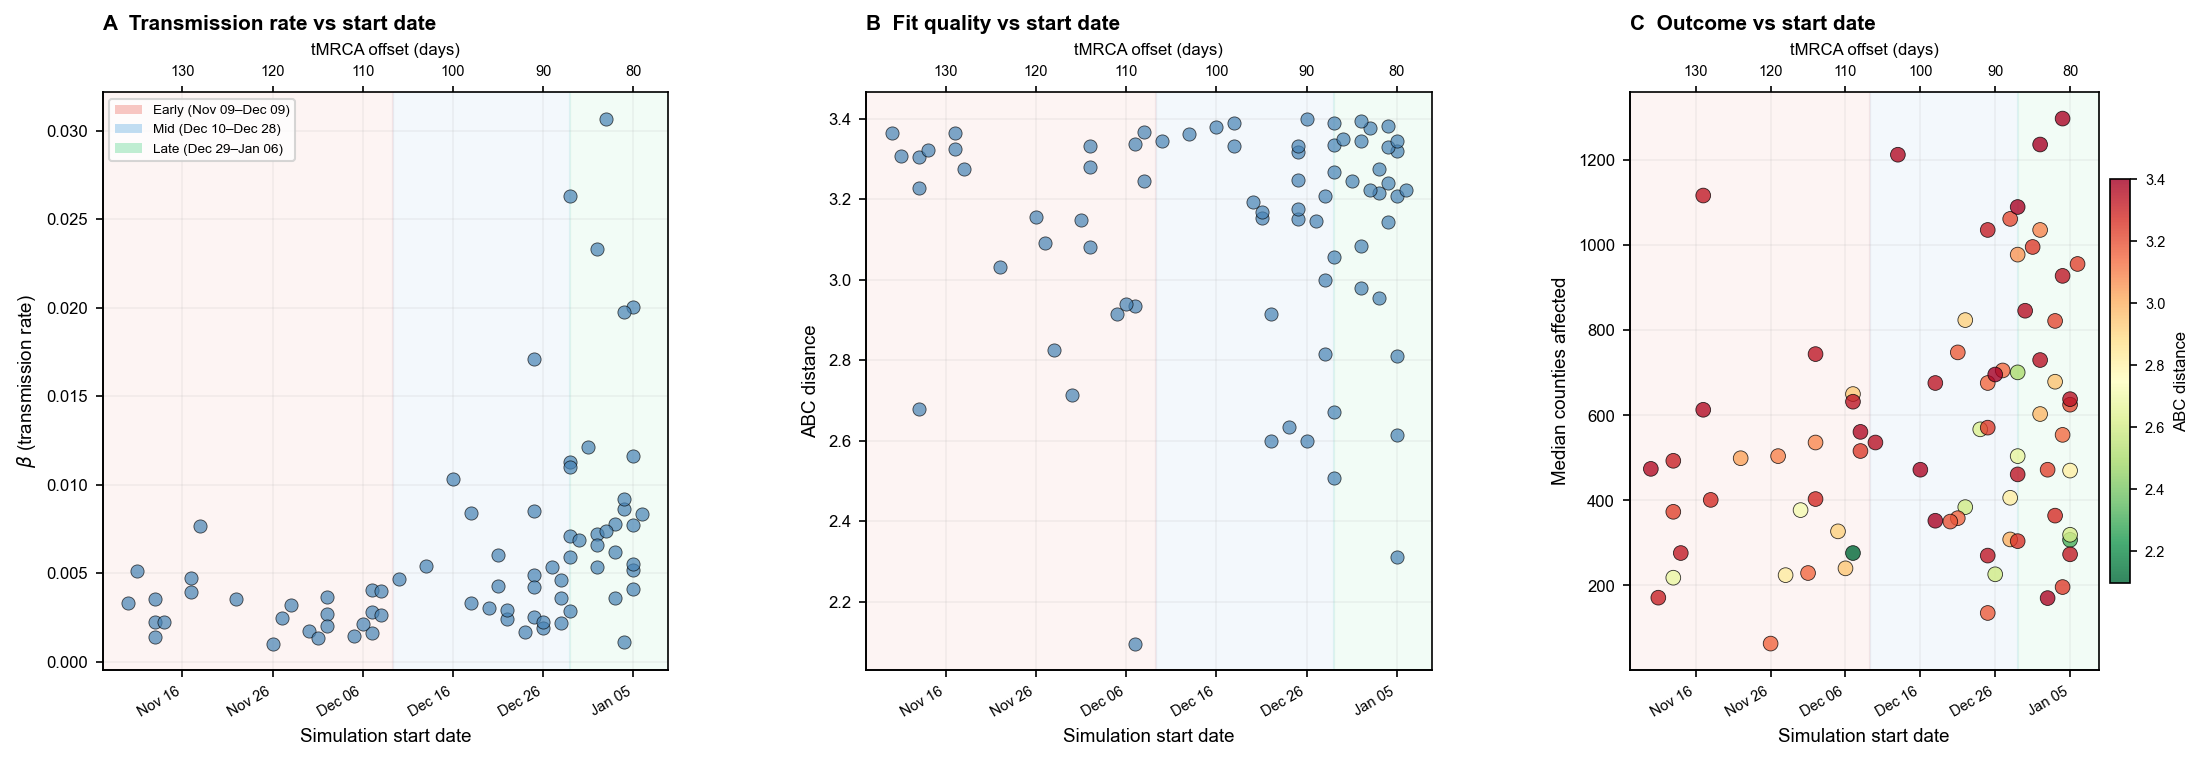

In [7]:
from matplotlib.patches import Patch

TX_DET = date(2024, 3, 25)

def offset_to_date(offset):
    return TX_DET - timedelta(days=int(offset))

offsets = abc_counties['tmrca_offset'].values

# Use ABC-derived tertile boundaries from cell 8 (consistent across all figures)
q33, q66 = tertile_edges[0], tertile_edges[1]
tick_offsets = [80, 90, 100, 110, 120, 130]

# Compute exact tertile date boundaries for legend
early_start = date(2023, 11, 9)  # fixed window start (earliest particle is Nov 10)
early_end = offset_to_date(int(np.ceil(q66)))
mid_start = offset_to_date(int(np.floor(q66)))
mid_end = offset_to_date(int(q33) + 1)  # +1 to avoid overlap with Late start
late_start = offset_to_date(int(np.floor(q33)))
late_end = offset_to_date(int(min(offsets)))

early_label = f'Early ({early_start.strftime("%b %d")}–{early_end.strftime("%b %d")})'
mid_label = f'Mid ({mid_start.strftime("%b %d")}–{mid_end.strftime("%b %d")})'
late_label = f'Late ({late_start.strftime("%b %d")}–{late_end.strftime("%b %d")})'

print(f'Tertile boundaries (from ABC particles): q33={q33:.2f}, q66={q66:.2f}')
print(f'  {early_label}  |  {mid_label}  |  {late_label}')

def add_offset_axis(ax_main):
    ax2 = ax_main.twiny()
    ax2.set_xlim(ax_main.get_xlim())
    ax2.set_xticks(tick_offsets)
    ax2.set_xticklabels([str(o) for o in tick_offsets], fontsize=7)
    ax2.set_xlabel('tMRCA offset (days)', fontsize=8, labelpad=5)
    ax2.tick_params(length=3)

def add_tertile_shading(ax_main):
    xlim = ax_main.get_xlim()
    lo, hi = min(xlim), max(xlim)
    ax_main.axvspan(lo, q33, color='#2ecc71', alpha=0.06, zorder=0)
    ax_main.axvspan(q33, q66, color='#3498db', alpha=0.06, zorder=0)
    ax_main.axvspan(q66, hi, color='#e74c3c', alpha=0.06, zorder=0)
    ax_main.set_xlim(xlim)

fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3, wspace=0.35)

# ── Panel A: β vs start date ──
ax = fig.add_subplot(gs[0, 0])
ax.scatter(offsets, abc_counties['beta'].values, s=40, c='steelblue', alpha=0.7,
           edgecolors='black', lw=0.4, zorder=3)
ax.invert_xaxis()
add_tertile_shading(ax)
ax.set_xticks(tick_offsets)
ax.set_xticklabels([offset_to_date(o).strftime('%b %d') for o in tick_offsets],
                   fontsize=7, rotation=30, ha='right')
ax.set_xlabel('Simulation start date', fontsize=9)
ax.set_ylabel(r'$\beta$ (transmission rate)', fontsize=9)
ax.set_title('A  Transmission rate vs start date', fontsize=10, fontweight='bold', loc='left')
ax.grid(True, alpha=0.15)
style_ax(ax)
add_offset_axis(ax)
ax.legend(handles=[
    Patch(facecolor='#e74c3c', alpha=0.3, label=early_label),
    Patch(facecolor='#3498db', alpha=0.3, label=mid_label),
    Patch(facecolor='#2ecc71', alpha=0.3, label=late_label),
], fontsize=6.5, loc='upper left', framealpha=0.8)

# ── Panel B: Fit quality vs start date ──
ax = fig.add_subplot(gs[0, 1])
ax.scatter(offsets, abc_counties['distance'].values, s=40, c='steelblue', alpha=0.7,
           edgecolors='black', lw=0.4, zorder=3)
ax.invert_xaxis()
add_tertile_shading(ax)
ax.set_xticks(tick_offsets)
ax.set_xticklabels([offset_to_date(o).strftime('%b %d') for o in tick_offsets],
                   fontsize=7, rotation=30, ha='right')
ax.set_xlabel('Simulation start date', fontsize=9)
ax.set_ylabel('ABC distance', fontsize=9)
ax.set_title('B  Fit quality vs start date', fontsize=10, fontweight='bold', loc='left')
ax.grid(True, alpha=0.15)
style_ax(ax)
add_offset_axis(ax)

# ── Panel C: Outcome vs start date, colored by fit quality ──
ax = fig.add_subplot(gs[0, 2])

dist_vals = abc_counties['distance'].values
norm_c = Normalize(vmin=dist_vals.min(), vmax=dist_vals.max())
cmap_c = plt.cm.RdYlGn_r

sc = ax.scatter(abc_counties['tmrca_offset'], abc_counties['med_counties_w104'],
                s=50, c=dist_vals, cmap=cmap_c, norm=norm_c, alpha=0.8,
                edgecolors='black', lw=0.4, zorder=3)
ax.invert_xaxis()
add_tertile_shading(ax)

cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('ABC distance', fontsize=8)
cbar.ax.tick_params(labelsize=7)

ax.set_xticks(tick_offsets)
ax.set_xticklabels([offset_to_date(o).strftime('%b %d') for o in tick_offsets],
                   fontsize=7, rotation=30, ha='right')
ax.set_xlabel('Simulation start date', fontsize=9)
ax.set_ylabel('Median counties affected', fontsize=9)
ax.set_title('C  Outcome vs start date', fontsize=10, fontweight='bold', loc='left')
ax.grid(True, alpha=0.15)
style_ax(ax)
add_offset_axis(ax)

fig.tight_layout()
# for ext in ['png', 'pdf']:
#     fig.savefig(FIG_DIR / f'S_StartDate.{ext}', dpi=300, bbox_inches='tight')
# print(f'Saved S_StartDate to {FIG_DIR}')
plt.show()

---

## Figure S-StratOutcomes: Stratified Outcomes by tMRCA Tertile

Three-panel figure showing how epidemic outcomes differ across start-date
tertiles (early/mid/late tMRCA offset).

- Whether earlier start dates produce larger outbreaks (more states, counties)
- Whether the number of pre-NPI interstate transmissions is sensitive to start date
- Degree of overlap between tertile distributions (high overlap = robust calibration)

In [8]:
abc_tertile_map = abc.reset_index()[['tertile']]
abc_tertile_map.index.name = 'param_idx'
abc_tertile_map = abc_tertile_map.reset_index()

results_t = results.merge(abc_tertile_map, on='param_idx', how='left')
print(f'Results with tertile: {results_t["tertile"].notna().sum():,} / {len(results_t):,}')
print(f'tmrca_offset range: {results_t["tmrca_offset"].min():.0f} – {results_t["tmrca_offset"].max():.0f}')

Results with tertile: 375,000 / 375,000
tmrca_offset range: 79 – 136


Using unified ABC tertile boundaries: q33=87.00, q66=106.67
  Early (Nov 09–Dec 09): 125,000 sims from 25 parameter sets
  Mid (Dec 10–Dec 28): 110,000 sims from 22 parameter sets
  Late (Dec 29–Jan 06): 140,000 sims from 28 parameter sets


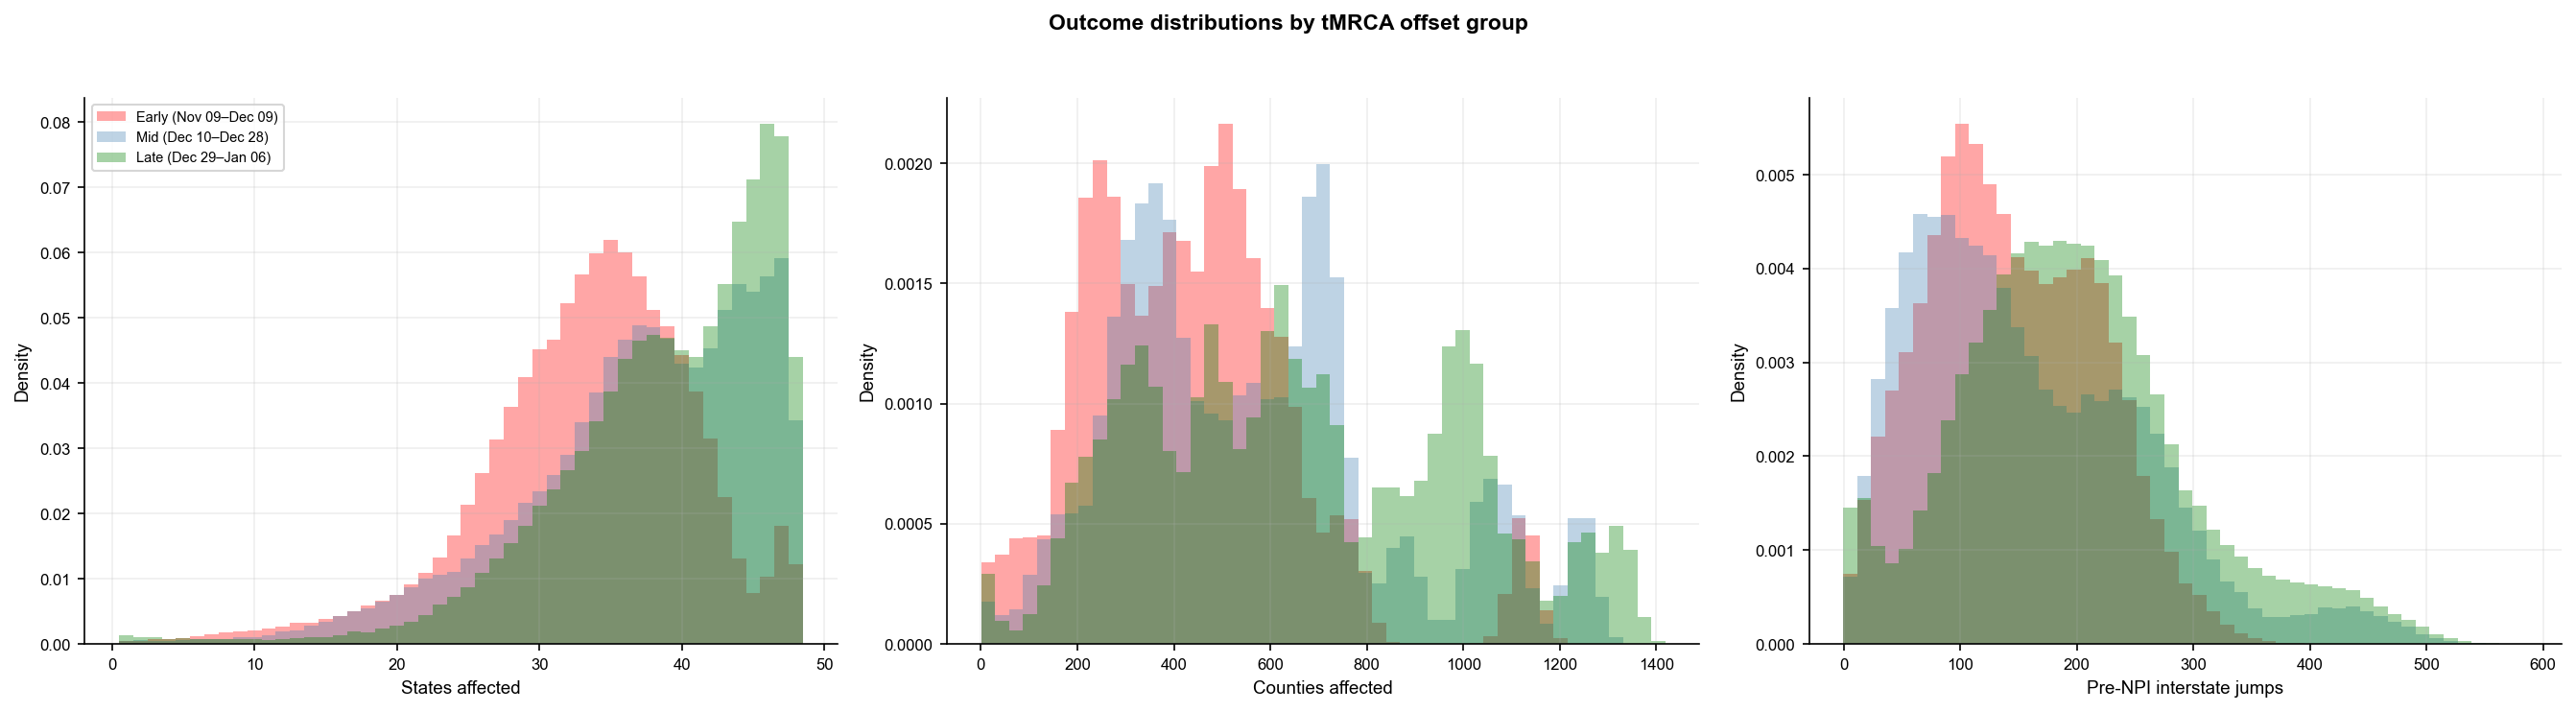

In [9]:
results_t['group'] = pd.cut(results_t['tmrca_offset'],
                             bins=[0, tertile_edges[0], tertile_edges[1], 200],
                             labels=['Late (short offset)', 'Mid', 'Early (long offset)'])

# Compute date boundaries using the unified tertile_edges
early_s = date(2023, 11, 9)  # fixed window start (earliest particle is Nov 10)
early_e = offset_to_date(int(np.ceil(tertile_edges[1])))
mid_s = offset_to_date(int(np.floor(tertile_edges[1])))
mid_e = offset_to_date(int(tertile_edges[0]) + 1)  # +1 to avoid overlap with Late start
late_s = offset_to_date(int(np.floor(tertile_edges[0])))
late_e = offset_to_date(int(results_t['tmrca_offset'].min()))

strat_colors = {
    'Early (long offset)': 'red',
    'Mid': 'steelblue',
    'Late (short offset)': 'green',
}
strat_legend = {
    'Early (long offset)': f'Early ({early_s.strftime("%b %d")}–{early_e.strftime("%b %d")})',
    'Mid': f'Mid ({mid_s.strftime("%b %d")}–{mid_e.strftime("%b %d")})',
    'Late (short offset)': f'Late ({late_s.strftime("%b %d")}–{late_e.strftime("%b %d")})',
}

print(f'Using unified ABC tertile boundaries: q33={tertile_edges[0]:.2f}, q66={tertile_edges[1]:.2f}')
for grp in ['Early (long offset)', 'Mid', 'Late (short offset)']:
    sub = results_t[results_t['group'] == grp]
    n_params = sub['param_idx'].nunique()
    print(f'  {strat_legend[grp]}: {len(sub):,} sims from {n_params} parameter sets')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

panel_configs = [
    ('n_states', 'States affected'),
    ('n_counties', 'Counties affected'),
    ('pre_interstate', 'Pre-NPI interstate jumps'),
]

for pi, (ax, (metric, label)) in enumerate(zip(axes, panel_configs)):
    all_vals = results_t[metric].dropna().values
    if metric == 'n_states':
        shared_bins = np.arange(all_vals.min() - 0.5, all_vals.max() + 1.5, 1)
    else:
        shared_bins = np.linspace(all_vals.min() - 0.5, all_vals.max() + 0.5, 50)

    for grp, color in strat_colors.items():
        sub = results_t[results_t['group'] == grp]
        vals = sub[metric].dropna().values
        ax.hist(vals, bins=shared_bins, color=color, alpha=0.35,
                density=True, label=strat_legend[grp])

    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    if pi == 0:
        ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)
    style_ax(ax)

fig.suptitle('Outcome distributions by tMRCA offset group',
             fontsize=11, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
# for ext in ['png', 'pdf']:
#     fig.savefig(FIG_DIR / f'S_StratOutcomes.{ext}', dpi=300, bbox_inches='tight')
# print(f'Saved S_StratOutcomes to {FIG_DIR}')
plt.show()

In [10]:
##### Manuscript statistics summary #####
print('=' * 70)
print('MANUSCRIPT STATISTICS — simulation_validation.ipynb')
print('=' * 70)

print(f'\n── S-M08 ──')
print(f'Total simulations: {N_SIMS:,}')
print(f'ABC particles: {len(abc)}')
print(f'States infected in ≥1 sim: {len(freq_df)}')
print(f'APHIS-confirmed states: {len(APHIS_STATES)} ({", ".join(APHIS_STATES)})')
print(f'Sims per particle: {N_SIMS // len(abc):,} (= 1,000 networks × 5 replicates)')

print(f'\n── S-StartDate ──')
print(f'tMRCA offset range: {int(abc["tmrca_offset"].min())}–{int(abc["tmrca_offset"].max())} days')
print(f'Start date range: {offset_to_date(int(abc["tmrca_offset"].max()))} to {offset_to_date(int(abc["tmrca_offset"].min()))}')
print(f'Unified tertile boundaries (abc.quantile([1/3, 2/3])): q33={tertile_edges[0]:.2f}, q66={tertile_edges[1]:.2f}')
print(f'  Early (red):  offset >{tertile_edges[1]:.0f}, dates {early_start} to {early_end}')
print(f'  Mid (blue):   offset {tertile_edges[0]:.0f}–{tertile_edges[1]:.0f}, dates {mid_start} to {mid_end}')
print(f'  Late (green): offset <{tertile_edges[0]:.0f}, dates {late_start} to {late_end}')

print(f'\n── S-StratOutcomes (same tertile boundaries) ──')
for grp in ['Early (long offset)', 'Mid', 'Late (short offset)']:
    sub = results_t[results_t['group'] == grp]
    n_params = sub['param_idx'].nunique()
    lo, hi = sub['tmrca_offset'].min(), sub['tmrca_offset'].max()
    print(f'  {strat_legend[grp]}: {len(sub):,} sims, {n_params} params, offset {lo:.0f}–{hi:.0f}, '
          f'dates {offset_to_date(int(hi))} to {offset_to_date(int(lo))}')

print(f'\n── Beta vs tMRCA offset ──')
rho, p = sp_stats.spearmanr(abc['tmrca_offset'], abc['beta'])
print(f'Spearman rho = {rho:.3f}, p = {p:.2e}')
print(f'Beta range: {abc["beta"].min():.4f}–{abc["beta"].max():.4f}')
print(f'Distance range: {abc["distance"].min():.4f}–{abc["distance"].max():.4f}')

print('\n' + '=' * 70)

MANUSCRIPT STATISTICS — simulation_validation.ipynb

── S-M08 ──
Total simulations: 375,000
ABC particles: 75
States infected in ≥1 sim: 48
APHIS-confirmed states: 16 (CA, CO, IA, ID, KS, MI, MN, NC, NE, NM, OH, OK, SD, TX, UT, WY)
Sims per particle: 5,000 (= 1,000 networks × 5 replicates)

── S-StartDate ──
tMRCA offset range: 79–136 days
Start date range: 2023-11-10 to 2024-01-06
Unified tertile boundaries (abc.quantile([1/3, 2/3])): q33=87.00, q66=106.67
  Early (red):  offset >107, dates 2023-11-09 to 2023-12-09
  Mid (blue):   offset 87–107, dates 2023-12-10 to 2023-12-28
  Late (green): offset <87, dates 2023-12-29 to 2024-01-06

── S-StratOutcomes (same tertile boundaries) ──
  Early (Nov 09–Dec 09): 125,000 sims, 25 params, offset 108–136, dates 2023-11-10 to 2023-12-08
  Mid (Dec 10–Dec 28): 110,000 sims, 22 params, offset 88–106, dates 2023-12-10 to 2023-12-28
  Late (Dec 29–Jan 06): 140,000 sims, 28 params, offset 79–87, dates 2023-12-29 to 2024-01-06

── Beta vs tMRCA offse